In [1]:
#importing libraries
import pandas as pd
import matplotlib.pyplot as plt
import ast as ast
import seaborn as sns

from datasets import load_dataset

#loading dataset
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

#cleaning
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills']= df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

#df_US

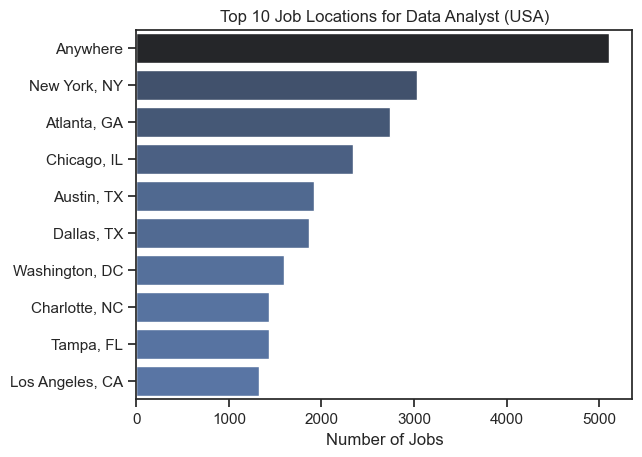

In [11]:
df_DA_US = df[(df['job_country'] == 'United States') & (df['job_title_short'] == 'Data Analyst')].copy()
df_plot =   df_DA_US['job_location'].value_counts().head(10).to_frame()

sns.set_theme(style='ticks')
sns.barplot(data=df_plot, x='count', y='job_location', hue='count', palette='dark:b_r', legend=False)
sns.despine
plt.title('Top 10 Job Locations for Data Analyst (USA)')
plt.xlabel('Number of Jobs')
plt.ylabel('')
plt.show()

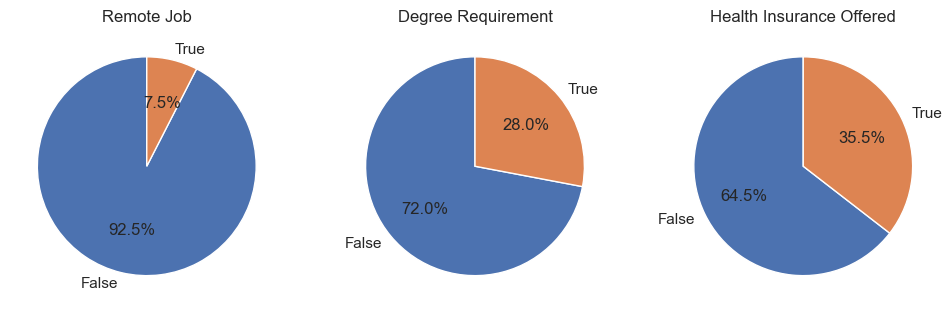

In [21]:
dict_column = {
    'job_work_from_home': 'Remote Job',
    'job_no_degree_mention': 'Degree Requirement',
    'job_health_insurance': 'Health Insurance Offered'
}
fig, ax = plt.subplots(1,3)
fig.set_size_inches(12,5)

for i, (column, title) in enumerate(dict_column.items()):
    ax[i].pie(df_DA_US[column].value_counts(),labels=['False', 'True'], autopct='%1.1f%%', startangle=90)
    ax[i].set_title(title)

plt.show()

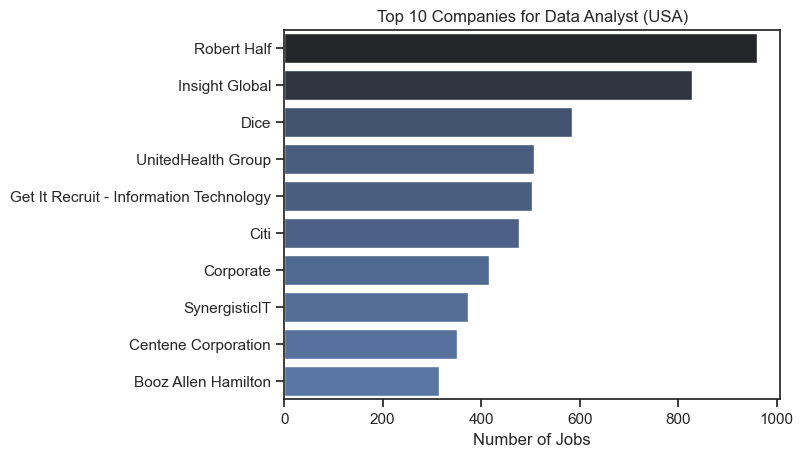

In [23]:
df_plot =   df_DA_US['company_name'].value_counts().head(10).to_frame()

sns.set_theme(style='ticks')
sns.barplot(data=df_plot, x='count', y='company_name', hue='count', palette='dark:b_r', legend=False)
sns.despine
plt.title('Top 10 Companies for Data Analyst (USA)')
plt.xlabel('Number of Jobs')
plt.ylabel('')
plt.show()